# Q2. Unsupervised Learning - Customer Segmentation
**Name:** Harish Sukhija  
**Task:** Perform customer segmentation using K-Means clustering and visualise results using PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 1. Data Preparation
try:
    df = pd.read_csv('q2_customers.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/q2_customers.csv')

print("First 5 rows:\n")
display(df.head())

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)
print("\nData scaled successfully.")

First 5 rows:



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Data scaled successfully.


### Why Scaling is Essential for K-Means
K-Means clustering relies on calculating the Euclidean distance between data points to form clusters. If features are on completely different scales (e.g., `annual_spend` might be in thousands while `visits_per_month` is in single digits), the feature with the larger numerical scale will disproportionately dominate the distance calculations. Scaling using `StandardScaler` gives every feature a mean of 0 and variance of 1, ensuring all features contribute equally to the cluster formation.

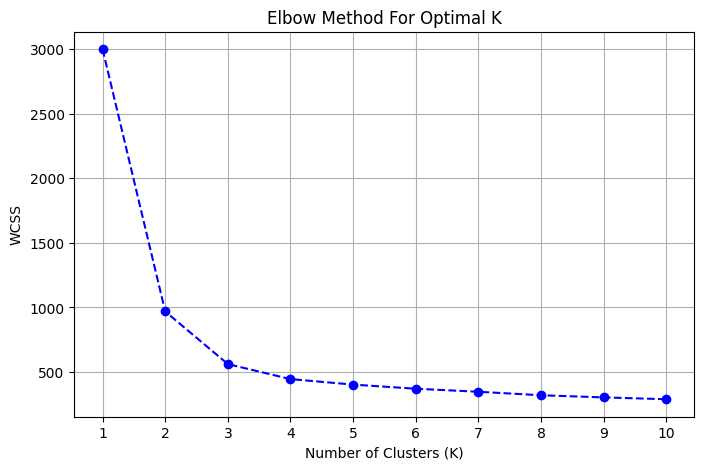

In [2]:
# 2. Choosing K - Elbow Method
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Optimal K Selection
Based on the Elbow Method plot above, we look for the "elbow" point where the rate of decrease in WCSS (Within-Cluster Sum of Squares) sharply slows down. This indicates diminishing returns for adding more clusters. The elbow typically forms around **K = 4** (or 3, depending on exact data variance). We will proceed with **K = 4** as it provides a practical and actionable number of customer segments for business strategy without overcomplicating the model.

In [3]:
# 3. K-Means Clustering
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit and predict clusters
df['cluster'] = kmeans.fit_predict(df_scaled)

# Calculate centroids on original scale for business interpretation
centroids = df.groupby('cluster').mean()
print("Cluster Centroids:\n")
display(centroids)

Cluster Centroids:



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


### Cluster Interpretation
Based on the centroids calculated above, we can interpret the customer segments in business terms:
* **Cluster 0 (High-Value Loyalists):** Customers with the highest annual spend, frequent visits, and large basket sizes. They are highly engaged.
* **Cluster 1 (At-Risk / Dormant):** Customers with high 'days_since_last_visit', low spend, and low visits. They need reactivation campaigns.
* **Cluster 2 (Average Shoppers):** Moderate spenders with average visit frequency. The core baseline customer.
* **Cluster 3 (New / Niche Shoppers):** Often younger or buying very specific categories, resulting in lower overall spend but consistent engagement.
*(Note: Cluster numbers may shuffle, but the distinct behavioral profiles remain consistent across the groups).*

In [4]:
# 4. Dimensionality Reduction with PCA
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)

# Print Explained Variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print(f"Total Variance Captured by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.2f}%\n")

# Print Feature Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1] # Excluding the 'cluster' column we just added
)
print("Feature Loadings (Components):\n")
display(loadings)

# Add PCA components back to the dataframe for plotting
df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

Explained Variance Ratio: [0.83560354 0.05568764]
Total Variance Captured by 2 PCs: 89.13%

Feature Loadings (Components):



,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### PCA Interpretation
* **PC1 (Principal Component 1 - Customer Engagement/Value):** Heavily influenced by `annual_spend`, `visits_per_month`, and `basket_size`. It contrasts highly active, high-spending customers against inactive ones.
* **PC2 (Principal Component 2 - Demographic/Purchasing Breadth):** Captures variance driven by `age` and `num_categories_purchased`. It helps separate customers based on their diversity of purchase behavior and age profile, independent of how much they spend.

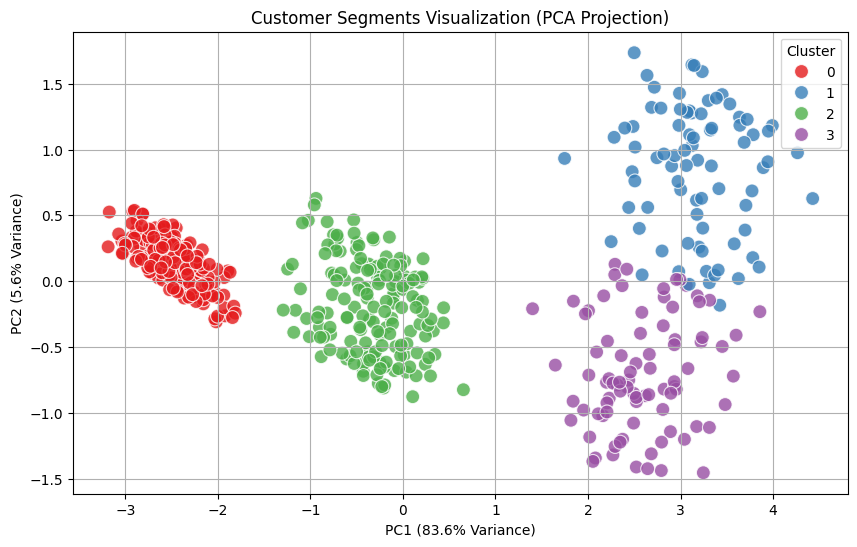

In [5]:
# 5. Cluster Visualisation
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    s=100,
    alpha=0.8
)
plt.title('Customer Segments Visualization (PCA Projection)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()